<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Ex_de_Apoio_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Redes Recorrentes para o processamento de dados textuais



*   Carregamento dos pacotes necessários
*   Carregamento dos dados (IMDB dataset)
*   Desenvolvimento de um modelo RNN Vanilla
*   Desenvolvimento de um modelo RNN LSTM



# Pacotes

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import SimpleRNN, Dense, Activation, Embedding, LSTM, Bidirectional
from keras.utils import pad_sequences
from keras.datasets import imdb

import pandas as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Carregamento de dados (IMDB)

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data

In [2]:
(X_train, Y_train), (X_test, Y_test) = imdb.load_data(
    path="imdb.npz",
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print("X_train: ", X_train.shape)
print("Y_train: ", Y_train.shape)
print("X_test: ", X_test.shape)
print("Y_test: ", Y_test.shape)

print("Classes existentes: ", np.unique(Y_train))

X_train:  (25000,)
Y_train:  (25000,)
X_test:  (25000,)
Y_test:  (25000,)
Classes existentes:  [0 1]


In [4]:
unique, cc = np.unique(Y_train, return_counts=True)
print("Distribuição das classes (treino): ", dict(zip(unique, cc)))

Distribuição das classes (treino):  {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}


In [5]:
unique, cc = np.unique(Y_test, return_counts=True)
print("Distribuição das classes (teste): ", dict(zip(unique, cc)))

Distribuição das classes (teste):  {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}


# Exemplos de Reviews (sentenças)

In [6]:
# Obtenção do dicionário (id --> palavra)
dicionario = imdb.get_word_index()
num_words = len(dicionario)
print("Número total de palavras no dicionário: ", num_words)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Número total de palavras no dicionário:  88584


In [7]:
# Algumas palavras (10 mais frequentes)
for (word, id) in dicionario.items():
  if id <= 10:
    print(id, word)

10 i
9 it
6 is
8 in
4 of
3 a
7 br
1 the
2 and
5 to


In [8]:
def Decode(idx = 1):
  reverse_index = dict([(id, word) for (word, id) in dicionario.items()])
  sentenca = " ".join([reverse_index.get(i - 3, "!") for i in X_train[idx]])
  return sentenca

In [9]:
# Exemplo de sentença (ids)
idx = 5
sentenca = Decode(idx)
print("Ids: ", np.array(X_train[idx])-3) # subtração do 3 - codificação inicial
print("Sentenca: ", sentenca)
print("Comprimento: ", len(X_train[idx]))
print("Classe: ", Y_train[idx])

Ids:  [   -2   775   125    71     9   627   160    12     1  1763  7979  1048
 43219    29    82   153    42    37   145   136   118   661   662     7
     7  1358   170     1   746 86585    13  3801     5     1   223    62
     9    40   124    21 15341     7     7]
Sentenca:  ! begins better than it ends funny that the russian submarine crew outperforms all other actors it's like those scenes where documentary shots br br spoiler part the message dechifered was contrary to the whole story it just does not mesh br br
Comprimento:  43
Classe:  0


# Pré-processamento

In [10]:
# reduzindo o número de palavras no dicionário
# para reduzir o número de parâmetros do modelo
num_words = 5000
(X_train, Y_train), (X_test, Y_test) = imdb.load_data(num_words = num_words)

maxlen = 100
embedding = 16


In [12]:
# Tamanho máximo da sentença
X_train = pad_sequences(X_train, maxlen = maxlen)
X_test = pad_sequences(X_test, maxlen = maxlen)

print(X_train[5])
decoded_review = Decode(5)

# palavras fora do dicionário (ausentes | > num_words)
# São subistituidos por oov_char (2)

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    1  778  128   74   12  630  163   15    4 1766    2 1051    2
   32   85  156   45   40  148  139  121  664  665   10   10 1361  173
    4  749    2   16 3804    8    4  226   65   12   43  127   24    2
   10   10]


# Modelo 01 - RNN Vanilla

In [18]:
modelo01 = keras.Sequential()
modelo01.add(Embedding(num_words, embedding, input_length=maxlen))
modelo01.add(SimpleRNN(10, return_sequences = True))
modelo01.add(SimpleRNN(10, return_sequences=False))
modelo01.add(Dense(1, activation="sigmoid"))

modelo01.build(input_shape=(None, maxlen))
modelo01.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 100, 10)        │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,491 (314.42 KB)

 Trainable params: 80,491 (314.42 KB)

 Non-trainable params: 0 (0.00 B)

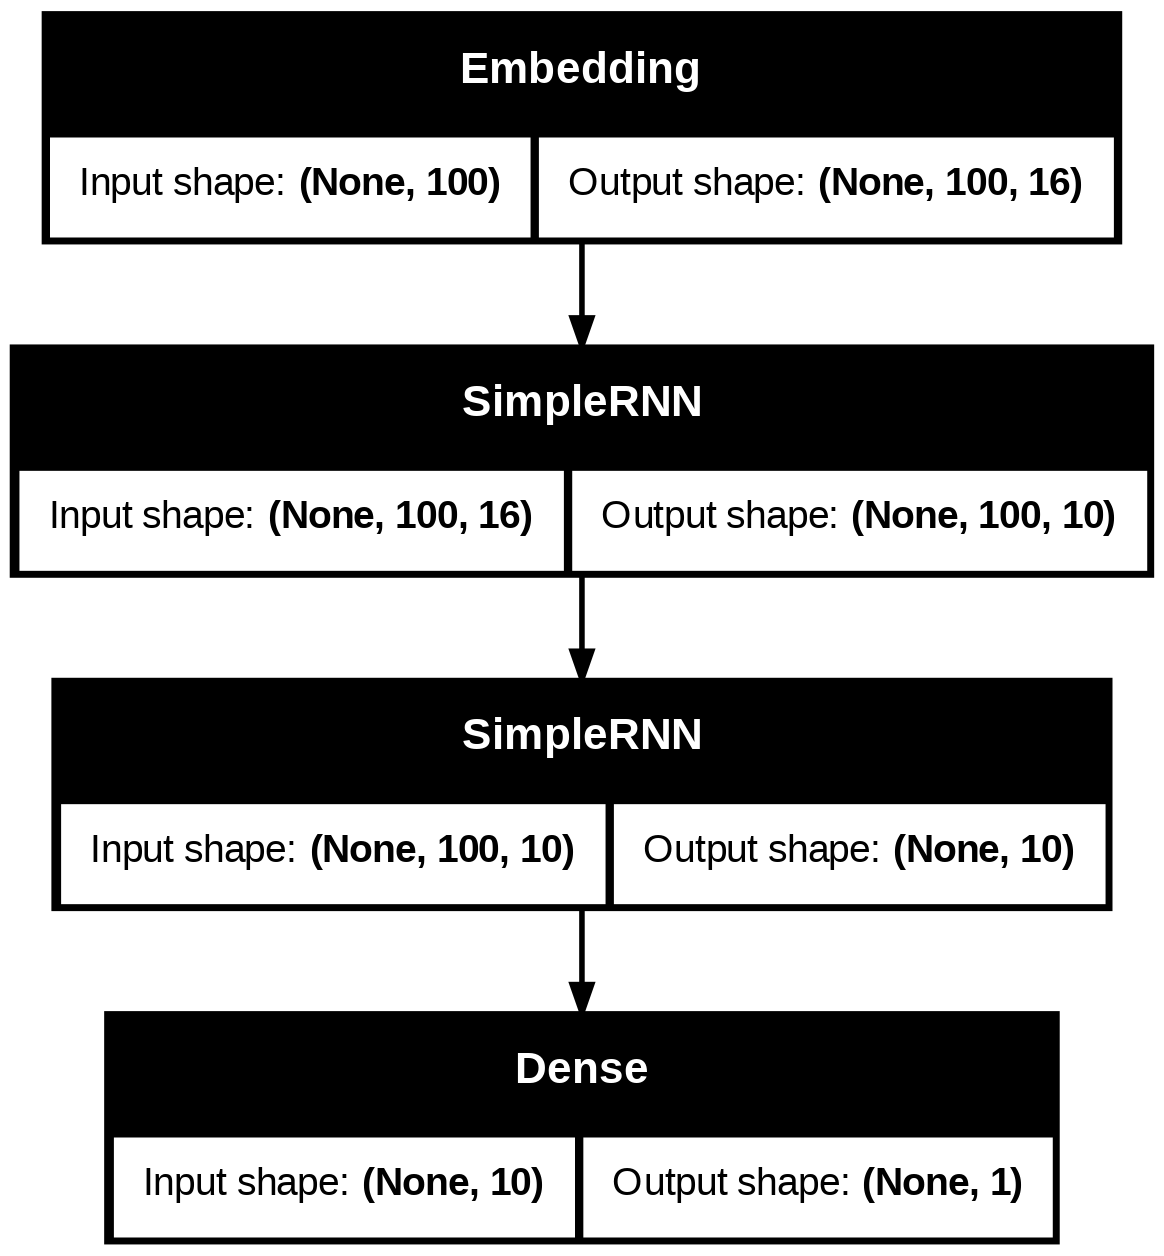

In [19]:
tf.keras.utils.plot_model(modelo01, show_shapes=True)

## Treinamento do Modelo

In [20]:
modelo01.compile(loss = "binary_crossentropy", optimizer = "rmsprop", metrics = ["accuracy"])
history = modelo01.fit(X_train, Y_train, validation_split = 0.1, epochs = 10, batch_size = 128, verbose = 1)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6767 - loss: 0.5995 - val_accuracy: 0.7976 - val_loss: 0.4443
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8288 - loss: 0.3998 - val_accuracy: 0.8272 - val_loss: 0.3867
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8624 - loss: 0.3318 - val_accuracy: 0.8296 - val_loss: 0.3825
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8788 - loss: 0.2956 - val_accuracy: 0.8216 - val_loss: 0.4242
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8965 - loss: 0.2643 - val_accuracy: 0.8352 - val_loss: 0.3805
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9080 - loss: 0.2363 - val_accuracy: 0.8388 - val_loss: 0.3889
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9257 - loss: 0.2028 - val_accuracy: 0.8224 - val_loss: 0.4327
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9349 - loss: 0.1790 - val_acc

## Avaliação

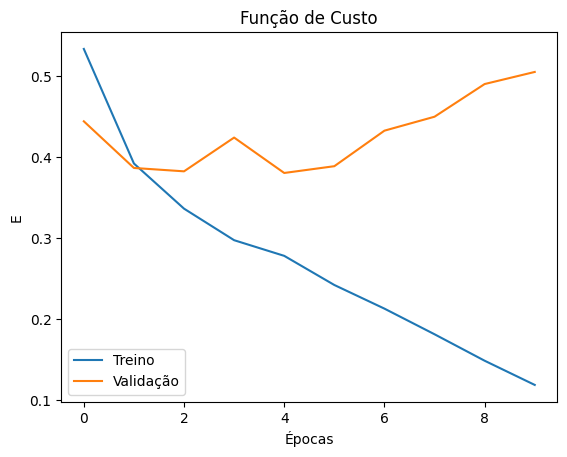

In [22]:
plt.figure()
plt.plot(history.history["loss"], label = "Treino")
plt.plot(history.history["val_loss"], label = "Validação")
plt.title("Função de Custo")
plt.ylabel("E")
plt.xlabel("Épocas")
plt.legend()
plt.show()

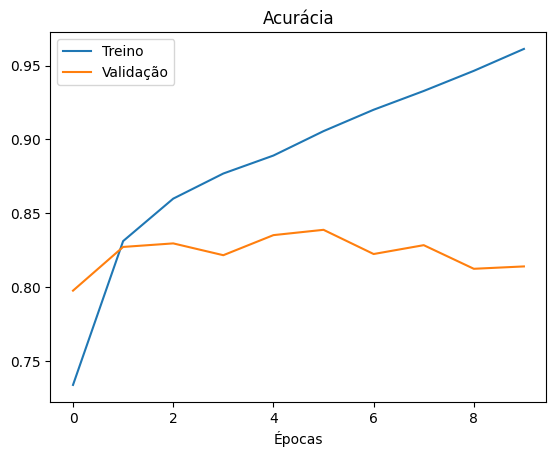

In [23]:
plt.figure()
plt.plot(history.history["accuracy"], label = "Treino")
plt.plot(history.history["val_accuracy"], label = "Validação")
plt.title("Acurácia")
plt.xlabel("Acurácia")
plt.xlabel("Épocas")
plt.legend()
plt.show()

In [24]:
score = modelo01.evaluate(X_test, Y_test)
print("Acurácia final: %", score[1]*100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8050 - loss: 0.5208
Acurácia final: % 80.77200055122375


## Confusion Matrix

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


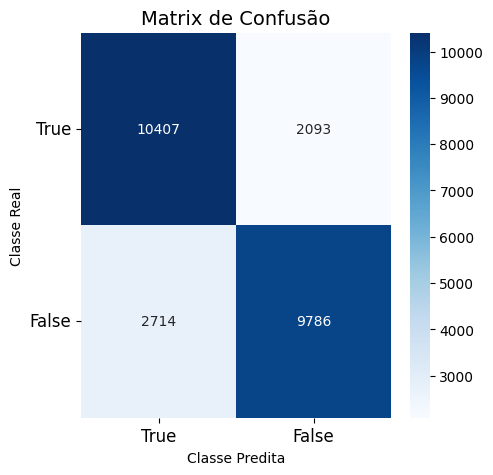

True Positive:  10407
True Negative:  9786
False Positive:  2093
False Negative:  2714


In [27]:
import pandas as pd
y_pred = modelo01.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(Y_test, y_pred)
df1 = pd.DataFrame(columns=["True", "False"], index = ["True", "False"], data = cm)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(df1, annot=True, cmap="Blues", fmt= '.0f', ax=ax)
plt.xlabel("Classe Predita")
plt.xticks(size = 12)
plt.yticks(size = 12, rotation=0)
plt.ylabel("Classe Real")
plt.title("Matrix de Confusão", size=14)
plt.show()

print("True Positive: ", cm[0][0])
print("True Negative: ", cm[1][1])
print("False Positive: ", cm[0][1])
print("False Negative: ", cm[1][0])

# Modelo LSTM

In [29]:
modelo02 = keras.Sequential()
modelo02.add(Embedding(num_words, embedding, input_length=maxlen))
modelo02.add(LSTM(10, return_sequences = True))
modelo02.add(LSTM(10, return_sequences=False))
modelo02.add(Dense(1, activation="sigmoid"))

modelo02.build(input_shape=(None, maxlen))
modelo02.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 16)        │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 10)        │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10)             │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,931 (320.04 KB)

 Trainable params: 81,931 (320.04 KB)

 Non-trainable params: 0 (0.00 B)

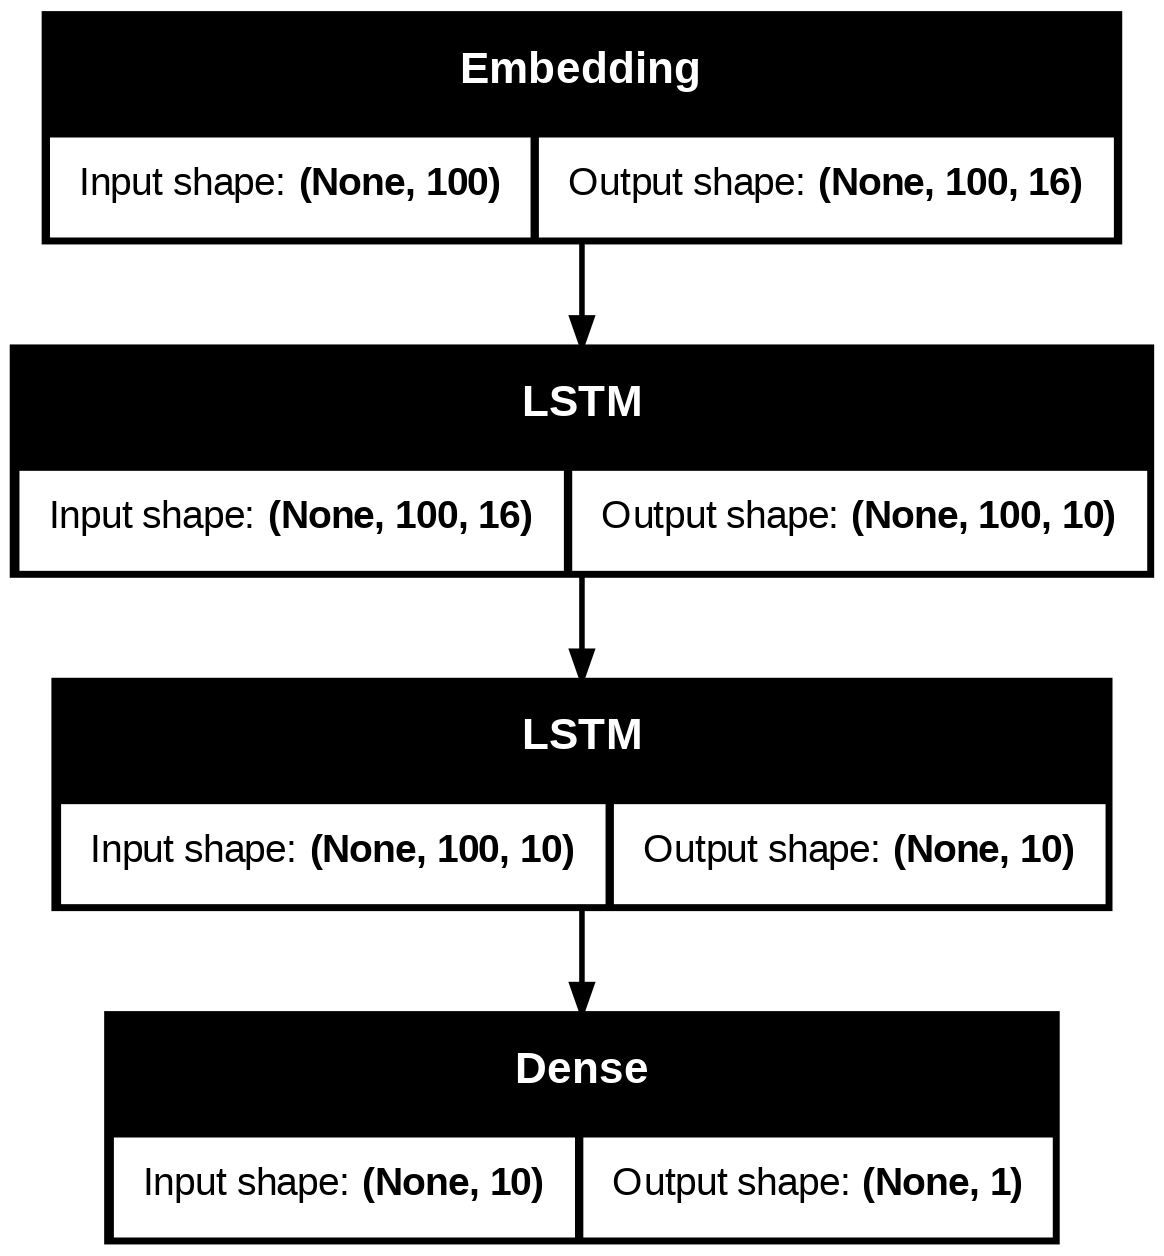

In [30]:
tf.keras.utils.plot_model(modelo02, show_shapes=True)

In [31]:
modelo02.compile(loss = "binary_crossentropy", optimizer = "rmsprop", metrics = ["accuracy"])
history = modelo02.fit(X_train, Y_train, validation_split = 0.1, epochs = 10, batch_size = 128, verbose = 1)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5473 - loss: 0.6783 - val_accuracy: 0.7696 - val_loss: 0.5046
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7884 - loss: 0.4645 - val_accuracy: 0.8232 - val_loss: 0.4011
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8430 - loss: 0.3734 - val_accuracy: 0.8304 - val_loss: 0.3726
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8653 - loss: 0.3275 - val_accuracy: 0.8444 - val_loss: 0.3614
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8793 - loss: 0.2987 - val_accuracy: 0.8480 - val_loss: 0.3556
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8920 - loss: 0.2783 - val_accuracy: 0.8476 - val_loss: 0.3474
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8950 - loss: 0.2614 - val_accuracy: 0.8236 - val_loss: 0.3945
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8924 - loss: 0.2640 - val_accu

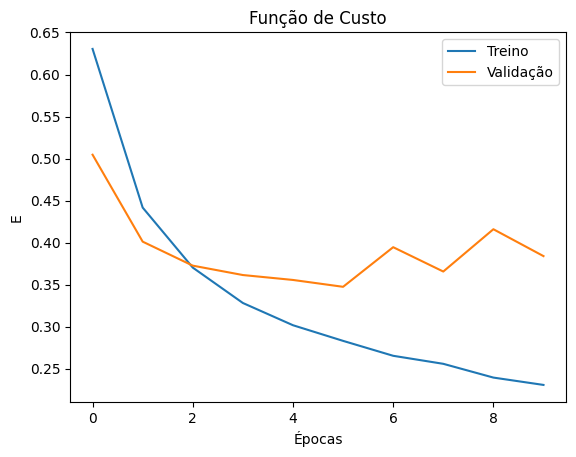

In [32]:
plt.figure()
plt.plot(history.history["loss"], label = "Treino")
plt.plot(history.history["val_loss"], label = "Validação")
plt.title("Função de Custo")
plt.ylabel("E")
plt.xlabel("Épocas")
plt.legend()
plt.show()

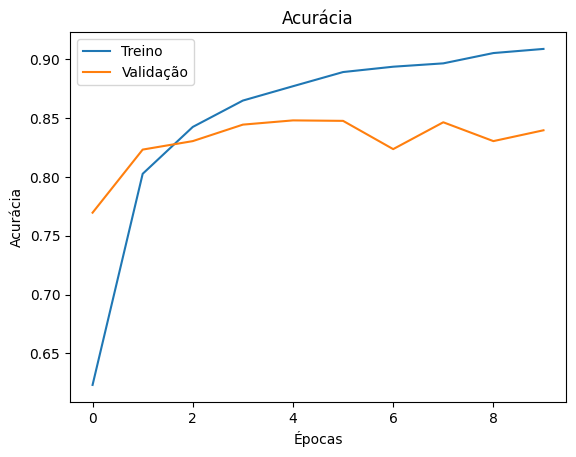

In [33]:
plt.figure()
plt.plot(history.history["accuracy"], label = "Treino")
plt.plot(history.history["val_accuracy"], label = "Validação")
plt.title("Acurácia")
plt.ylabel("Acurácia")
plt.xlabel("Épocas")
plt.legend()
plt.show()

In [34]:
score = modelo02.evaluate(X_test, Y_test)
print("Acurácia final: %", score[1]*100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8433 - loss: 0.3876
Acurácia final: % 84.44799780845642


## Confusion Matrix

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


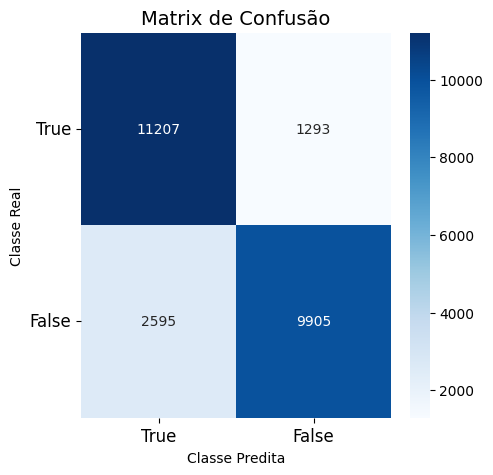

True Positive:  11207
True Negative:  9905
False Positive:  1293
False Negative:  2595


In [35]:
y_pred = modelo02.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(Y_test, y_pred)
df1 = pd.DataFrame(columns=["True", "False"], index = ["True", "False"], data = cm)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(df1, annot=True, cmap="Blues", fmt= '.0f', ax=ax)
plt.xlabel("Classe Predita")
plt.xticks(size = 12)
plt.yticks(size = 12, rotation=0)
plt.ylabel("Classe Real")
plt.title("Matrix de Confusão", size=14)
plt.show()

print("True Positive: ", cm[0][0])
print("True Negative: ", cm[1][1])
print("False Positive: ", cm[0][1])
print("False Negative: ", cm[1][0])